#### Imports


In [1]:
import os
# TensorFlow and tf.keras
import tensorflow as tf
# Helper libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [12]:
MODEL_DIR = "model"
KERAS_PATH = os.path.join(MODEL_DIR, "gesture_classifier.keras")

#### Load CSV dataset


In [3]:
CSV_PATH = "data/dataset.csv"

RANDOM_SEED = 42
NUM_FEATURES = 84       # 42 (x,y) right landmark and 42 (x,y) left landmark
NUM_CLASSES = 15        # [I, need, Accident, Fire, Yes, No, Ambulance, Doctor, Police, fireman, hurt, emergency, short of breath, help, stop]

data = np.loadtxt(CSV_PATH,delimiter=",",dtype=np.float32)
y = data[:,0].astype(np.float32)
X = data[:, 1:1 +NUM_FEATURES].astype(np.float32)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.min(y), "to", np.max(y))

X shape: (59999, 84)
y shape: (59999,)
Labels: 0.0 to 14.0


#### Train/test split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=RANDOM_SEED, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (47999, 84) Test: (12000, 84)


#### Build Model

In [57]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(NUM_FEATURES,)),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_13 (Dropout)            │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,887 (249.56 KB)

 Trainable params: 63,887 (249.56 KB)

 Non-trainable params: 0 (0.00 B)

#### Train Model

In [58]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
history = model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=128, callbacks=[early_stop])

Epoch 1/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6638 - loss: 1.0319 - val_accuracy: 0.8535 - val_loss: 0.4905
Epoch 2/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7997 - loss: 0.6023 - val_accuracy: 0.8815 - val_loss: 0.3793
Epoch 3/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8268 - loss: 0.5224 - val_accuracy: 0.8994 - val_loss: 0.3317
Epoch 4/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8437 - loss: 0.4727 - val_accuracy: 0.9120 - val_loss: 0.3052
Epoch 5/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8567 - loss: 0.4319 - val_accuracy: 0.9155 - val_loss: 0.2857
Epoch 6/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8652 - loss: 0.4103 - val_accuracy: 0.9229 - val_loss: 0.2632
Epoch 7/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8738 - loss: 0.3842 - val_accuracy: 0.9227 - val_loss: 0.2597
Epoch 8/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8785 - loss: 0.3662 - val_accu

#### Evaluate accuracy

In [59]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print('\nTest Accuracy:', round(test_acc,4))
print('\nTest Loss:', round(test_loss,4))

375/375 - 0s - 411us/step - accuracy: 0.9550 - loss: 0.1465

Test Accuracy: 0.955

Test Loss: 0.1465


#### Visualization of Training Evaluation

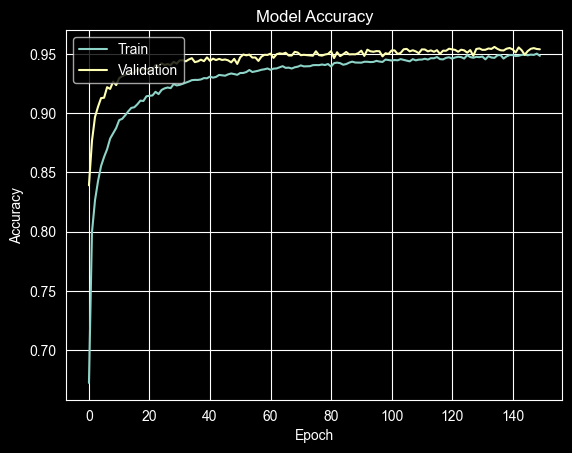

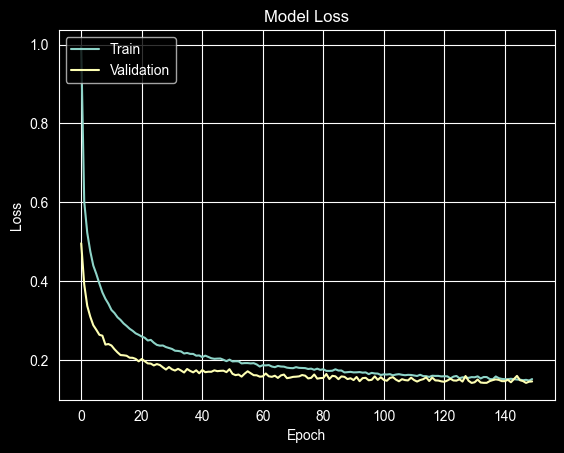

In [42]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Make Prediction

In [48]:
# Inference
y_pred_prob = model.predict(X_test)

# prediction
y_pred = np.argmax(y_pred_prob, axis=1)

# Print example to see if the predict with match the true label
print("Predict label:",y_pred[0])    # ground-truth labels from the dataset
print("True label:", y_test[0])      # the correct label for the same sample

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step
Predict label: 10
True label: 10.0


#### Save Trained Model


In [46]:
os.makedirs(MODEL_DIR, exist_ok=True)
# Save Keras model
model.save(KERAS_PATH, include_optimizer=False)

#### Confusion Matrix

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step


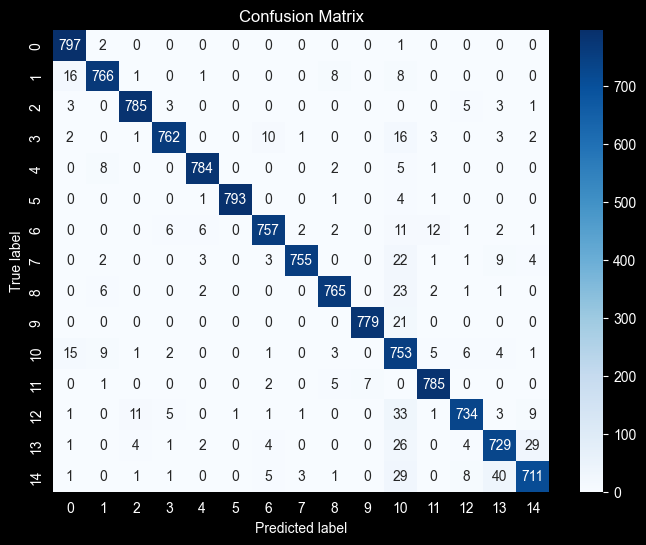

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       800
           1       0.96      0.96      0.96       800
           2       0.98      0.98      0.98       800
           3       0.98      0.95      0.96       800
           4       0.98      0.98      0.98       800
           5       1.00      0.99      0.99       800
           6       0.97      0.95      0.96       800
           7       0.99      0.94      0.97       800
           8       0.97      0.96      0.96       800
           9       0.99      0.97      0.98       800
          10       0.79      0.94      0.86       800
          11       0.97      0.98      0.97       800
          12       0.97      0.92      0.94       800
          13       0.92      0.91      0.91       800
          14       0.94      0.89      0.91       800

    accuracy                           0.95     12000
   macro avg       0.96      0.95      0.96     12000
weig

In [47]:
# Predict labels
y_pred = np.argmax(model.predict(X_test), axis=1)

# all labels (0–14) to appear
labels = list(range(15))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Convert to DataFrame (this is to print all labels)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("Classification Report")
print(classification_report(y_test, y_pred, labels=labels))